# After the Bohr magneton: electron spin, the g-factor, Stern-Gerlach
### the factor of 2 that broke the Bohr picture and revealed spin

The Bohr magneton $\mu_B$ is the magnetic moment of one unit of *orbital* angular
momentum. The next discovery: the electron also has **spin**, and its spin magnetic
moment is about **twice** as big per unit -- the **g-factor** $g_s\approx2.0023$.
That factor of 2 is the whole story here:

- **Stern-Gerlach:** a spin-1/2 beam in a field *gradient* splits into exactly **two**
  spots (space quantization), not the continuous smear classical physics predicts.
- **Anomalous Zeeman:** because the effective $g$ (the Lande $g_J$) differs between
  levels, a line splits into **more than three** components -- the "anomalous" case
  that the normal (orbital-only, $g=1$) triplet is just a special case of.

All in `griffiths/atomic.py`. Civilian education / atomic physics.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from griffiths import atomic as at
print(f"electron g-factor g_s = {at.electron_g_factor()}")
print(f"spin moment = {at.spin_magnetic_moment()/at.MU_B:.4f} Bohr magnetons (from 1/2 unit of spin)")

electron g-factor g_s = 2.00231930436
spin moment = 1.0012 Bohr magnetons (from 1/2 unit of spin)


## 1. Stern-Gerlach: two spots, not a smear

An inhomogeneous field exerts a force $F_z=g\,m_s\,\mu_B\,\partial B/\partial z$ on a
magnetic moment. **Classically** $m_s$ could be anything, so the beam would spread
into a continuous band. **Quantum-mechanically** $m_s=\pm\tfrac12$ only, so the beam
splits into two discrete spots -- the experiment that proved spin is quantized.

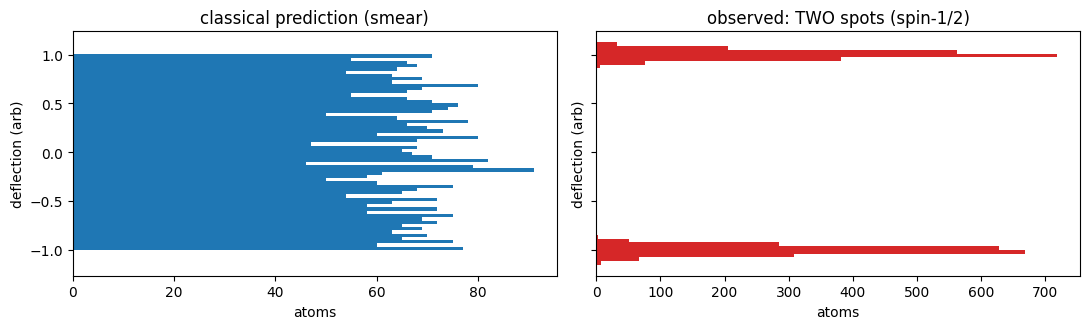

F_up = 9.284764698677923e-21 N;  F_dn = -9.284764698677923e-21 N (equal, opposite)


In [2]:
rng = np.random.default_rng(0); n = 4000
dBdz = 1e3
# classical: mu_z uniform in [-1,1] * (g/2) mu_B -> continuous deflection band
classical = np.random.uniform(-1, 1, n) * at.electron_g_factor()*0.5
# quantum: m_s = +/- 1/2 only -> two forces
quantum = np.random.choice([-0.5, 0.5], n) * at.electron_g_factor()
quantum = quantum + 0.04*rng.standard_normal(n)              # tiny beam width for visibility
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
ax[0].hist(classical, bins=60, orientation="horizontal", color="C0"); ax[0].set_title("classical prediction (smear)")
ax[1].hist(quantum, bins=60, orientation="horizontal", color="C3"); ax[1].set_title("observed: TWO spots (spin-1/2)")
for a in ax: a.set_xlabel("atoms"); a.set_ylabel("deflection (arb)")
plt.tight_layout(); plt.show()
print("F_up =", at.stern_gerlach_force(0.5, dBdz), "N;  F_dn =", at.stern_gerlach_force(-0.5, dBdz), "N (equal, opposite)")

## 2. The Lande g-factor -- combining orbital and spin

When orbital ($l$) and spin ($s$) angular momenta combine into total $j$, the
effective magnetic g is
$$g_J=1+\frac{j(j+1)+s(s+1)-l(l+1)}{2j(j+1)}.$$
It is **1** for pure orbital ($s=0$, the normal Zeeman case) and **2** for pure spin
($l=0$). The sodium D terms give the textbook values $2,\ \tfrac23,\ \tfrac43$.

In [3]:
terms = {"2S_1/2 (l=0,s=1/2,j=1/2)": (0,.5,.5), "2P_1/2 (l=1,s=1/2,j=1/2)": (1,.5,.5),
         "2P_3/2 (l=1,s=1/2,j=3/2)": (1,.5,1.5), "pure orbital (s=0)": (2,2,0)}
for name,(l,s,j) in terms.items():
    print(f"  g_J({name}) = {at.lande_g_factor(j,l,s):.4f}")

  g_J(2S_1/2 (l=0,s=1/2,j=1/2)) = 2.0000
  g_J(2P_1/2 (l=1,s=1/2,j=1/2)) = 0.6667
  g_J(2P_3/2 (l=1,s=1/2,j=3/2)) = 1.3333
  g_J(pure orbital (s=0)) = 0.0000


## 3. The anomalous Zeeman effect -- more than three lines

Each level splits by $g_J m_j\mu_B B$. Because the lower and upper levels have
*different* $g_J$, the transition $\Delta m_j\in\{-1,0,+1\}$ produces **more than
three** components. The sodium D1 line ($^2P_{1/2}\to{}^2S_{1/2}$) splits into four.
The normal triplet only appears when $g$ is the same (pure orbital).

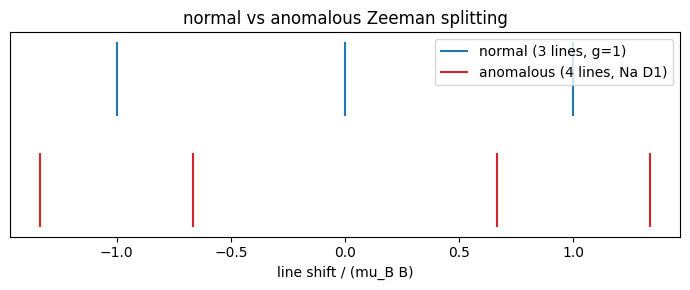

normal: [np.float64(-1.0), np.float64(0.0), np.float64(1.0)]  anomalous (Na D1): [np.float64(-1.333333), np.float64(-0.666667), np.float64(0.666667), np.float64(1.333333)]


In [4]:
B = 1.0
def lines(g_up, g_low):
    up = {mj: at.anomalous_zeeman_shift(mj, g_up, B) for mj in (-0.5, 0.5)}
    low = {mj: at.anomalous_zeeman_shift(mj, g_low, B) for mj in (-0.5, 0.5)}
    out = []
    for mu, Eu in up.items():
        for ml, El in low.items():
            if abs(mu-ml) <= 1: out.append((Eu-El)/(at.MU_B*B))
    return sorted(set(np.round(out,6)))
anom = lines(2/3, 2.0)            # sodium D1: 2P_1/2 -> 2S_1/2
norm = lines(1.0, 1.0)            # pure orbital both -> normal triplet
plt.figure(figsize=(7,3))
plt.vlines(norm, 0.6, 1.0, color="C0", label=f"normal ({len(norm)} lines, g=1)")
plt.vlines(anom, 0.0, 0.4, color="C3", label=f"anomalous ({len(anom)} lines, Na D1)")
plt.yticks([]); plt.xlabel("line shift / (mu_B B)"); plt.legend()
plt.title("normal vs anomalous Zeeman splitting"); plt.tight_layout(); plt.show()
print("normal:", norm, " anomalous (Na D1):", anom)

## What comes after the Bohr magneton

1. **Electron spin** -- and its moment is ~2 Bohr magnetons per unit ($g_s\approx2$),
   the factor that Dirac's equation explains (and QED nails to 2.0023).
2. **Stern-Gerlach:** the moment is *space-quantized* -- a spin-1/2 beam splits into
   two, proving angular momentum (and spin) is discrete.
3. **Lande g-factor** combines $l$ and $s$; the **anomalous Zeeman** effect (more than
   three lines) is the general rule, the normal triplet the exception.

The Bohr magneton was the orbital unit; spin, $g\approx2$, and the Lande factor are
what come next -- and they run magnetometry, MRI, and spintronics. Civilian education.